![logo](https://github.com/HelmholtzAI-Consultants-Munich/XAI-Tutorials/blob/main/docs/source/_figures/Helmholtz-AI.png?raw=true)

# Model-Agnostic Interpretation with LIME for Image Analysis

In this notebook, we will demonstrate how to use the Local Interpretable Model-agnostic Explanations (LIME) method for image classification models.

--------

## Getting Started

### Setup Colab environment

If you installed the packages and requirements on your machine, you can skip this section and start from the import section.
Otherwise, you can follow and execute the tutorial on your browser. To start working on the notebook, click on the following button. This will open this page in the Colab environment, and you will be able to execute the code on your own.

<a href="https://colab.research.google.com/github/HelmholtzAI-Consultants-Munich/XAI-Tutorials/blob/main/xai-for-cnn/4-Tutorial_LIME_Images.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Now that you opened the notebook in Google Colab, follow the next step:

1. Run this cell to connect your Google Drive to Colab and install packages
2. Allow this notebook to access your Google Drive files. Click on 'Yes', and select your account.
3. "Google Drive for desktop wants to access your Google Account". Click on 'Allow'.
   
At this point, a folder has been created in your Drive, and you can navigate it through the lefthand panel in Google Colab. You might also have received an email that informs you about the access on your Google Drive.

In [1]:
# Mount drive folder to dbe abale to download repo
# from google.colab import drive
# drive.mount('/content/drive')

# Switch to correct folder'
# %cd /content/drive/MyDrive

In [ ]:
# Don't run this cell if you already cloned the repo 
# %rm -r XAI-Tutorials
# !git clone --branch main https://github.com/HelmholtzAI-Consultants-Munich/XAI-Tutorials.git

In [ ]:
# Install al required dependencies and package versions
# %cd XAI-Tutorials
# !pip install -r requirements_xai-for-cnn.txt
# %cd xai-for-cnn

### Imports

Let's start with importing all required Python packages.

In [1]:
import numpy as np
from lime import lime_image
from skimage.segmentation import mark_boundaries

import torch
from torchvision import models
from torchvision.models.inception import Inception_V3_Weights

import sys
sys.path.append('./')
import utils

import matplotlib.pyplot as plt
%matplotlib inline

Now, we fix the random seeds to ensure reproducible results, as we work with (pseudo) random numbers.

In [2]:
# assert reproducible random number generation
seed = 1
np.random.seed(seed)
torch.manual_seed(seed)

--------

## Data and Model Loading

Let's use an image of an ananas.

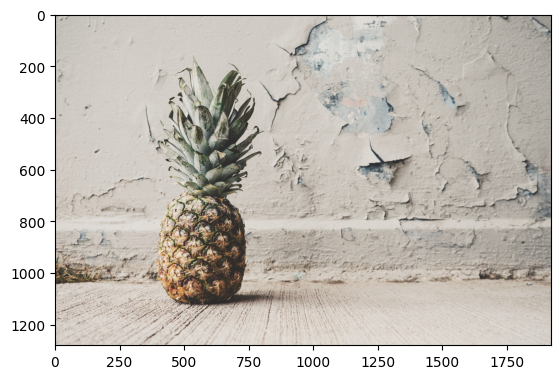

In [3]:
file_img = '../data/images/pineapple.jpg'

img = utils.read_image_PIL(file_img)
plt.imshow(img)

We have to apply some transformations to ensure the input data has the correct format and is optimized for model training and inference. If you want to know more about these transformations, you can have a look at the [*utils.py*](utils.py) file.

In [4]:
# load function to resize and center crop
pill_transf = utils.get_pil_transform()

As model, we choose the pre-trained Inception V3 architecture ([Szegedy et al., 2015](https://arxiv.org/pdf/1512.00567.pdf)) available along PyTorch. Inception V3 improved upon its predecessor by incorporating smaller kernel size, factorized convolution, auxiliary classifier, and batch normalization to improve efficiency, reduce the computational cost, and combat the vanishing gradient problem.

In [5]:
model = models.inception_v3(weights=Inception_V3_Weights.DEFAULT)

Predictions for a batch of images can be generated through the ```batch_predict``` function, which returns a batch of predicted probabilities for each class. Then, we extract the index of the class with the highest probability in the flattened array, indicating the predicted class label.

In [6]:
# Make preditction
pred = utils.batch_predict([pill_transf(img)], model)

# Extract class with highest prbability
top_class = pred.squeeze().argmax()
print(f"The predicted class with the highest probability is: {top_class}")

The predicted class with the highest probability is: 953


Get class name from [here](https://deeplearning.cms.waikato.ac.nz/user-guide/class-maps/IMAGENET/) and check if the prediction is correct.

## Now, what does my model think is important in the data?

**We prepared a small [Introduction to LIME](https://xai-tutorials.readthedocs.io/en/latest/_model_agnostic_xai/lime.html) for you, to help you understand how this method works. In the section [LIME for Image Classification](https://xai-tutorials.readthedocs.io/en/latest/_model_agnostic_xai/lime.html#lime-for-image-classification) we prepared an introduction on how to apply LIME on image data.**

*Note: we provide all references [here](https://xai-tutorials.readthedocs.io/en/latest/_model_agnostic_xai/lime.html#references).*

<font color='green'>

#### Question 1: What is a surrogate model?

<font color='grey'>

#### Your Answer: 
It’s an interpretable model, such as linear or tree models, that approximates the prediction of a more complex model.


<font color='green'>

#### Question 2: How is LIME using surrogate models to explain a model prediction?

<font color='grey'>

#### Your Answer: 
It creates the dataset from n perturbed images and lets the complex model make predictions for those perturbed images. This data set is then used to fit a surrogate model which can than be analysed to identify important features.

Now, let's use LIME to get insights into the image classification model. To utilize LIME for image explanations, the first step is to instantiate the ```LimeImageExplainer()``` class. Subsequently, the ```explain_instance``` method is employed with the following parameters:

- ```image```: the image represented as a Numpy array.
- ```classifier_fn```: the model used for making predictions.
- ```segmentation_fn```: the model used for segmentation of superpixels. Segmentation models are taken from [scikit-image](https://scikit-image.org/docs/stable/api/skimage.segmentation.html).
- ```top_labels```: the number of top classes for which explanations are generated.
- ```hide_color```: the color assigned to non-activated superpixels (set to a specific color, or 'avg' to use the mean over the superpixel region).
- ```num_samples```: the size of the neighborhood to learn the linear model.
- ```random_seed```: to ensure reproducibility in the segmentation, set the random seed for consistent results.
  
For more details about all the possible parameters, check out the [LIME documentation](https://lime-ml.readthedocs.io/en/latest/lime.html#module-lime.lime_image).
 
In our specific instance, explanations are generated for the top 5 classes, and the background color for non-activated superpixels is set to black.

In [7]:
explainer = lime_image.LimeImageExplainer()
explanation = explainer.explain_instance(image=np.array(pill_transf(img)), 
                                         classifier_fn=lambda images: utils.batch_predict(images, model), 
                                         top_labels=5, 
                                         hide_color=None, 
                                         num_samples=1000,
                                         random_seed=42) 

  0%|          | 0/1000 [00:00<?, ?it/s]

To visualize the instance explanation, the ```get_image_and_mask``` method can be utilized with the following configurable parameters:

- ```label```: the label for which the explanation is desired.
- ```positive_only```: if ```True```, considers only superpixels that positively contribute to the prediction of the label.
- ```negative_only```: if ```True```, considers only superpixels that negatively contribute to the prediction of the label. If ```False```, both negative and positive contributions are considered. Note that both cannot be ```True``` simultaneously.
- ```hide_rest```: if ```True```, renders the non-explanation part of the return image in gray.
- ```num_features```: the number of superpixels to include in the explanation.
-  ```min_weight```: minimum weight of the superpixels to include in the explanation 
   
We will show three scenarios: one where positive contributions (```positive_only```)are active, another where negative contributions (```negative_only```) are active, and a third where both are included simultaneously (both set to False).

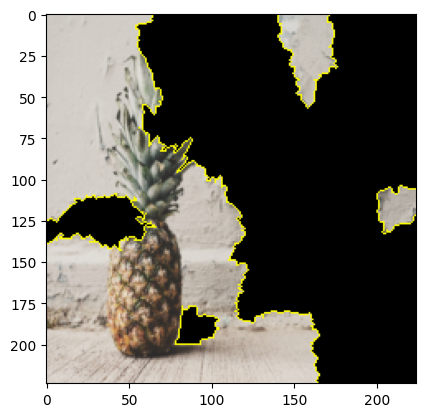

In [8]:
# Plot mask with positive contributions
label_to_explain = 0
temp, mask = explanation.get_image_and_mask(
    label=explanation.top_labels[label_to_explain],
    positive_only=True,
    negative_only=False,
    num_features=10,
    hide_rest=True,
    min_weight=0,
)
normalized_temp = temp / 255.0
img_boundry1 = mark_boundaries(normalized_temp, mask)
plt.imshow(img_boundry1)

In this first example, we set ```num_features=10```, meaning that we want to extract the top 10 features (segmented areas) that contribute most to predicting the ananas. In other words, our model heavily depends on the ten segmented areas to recognize the ananas in the image. Try to change this parameter and see what happens.

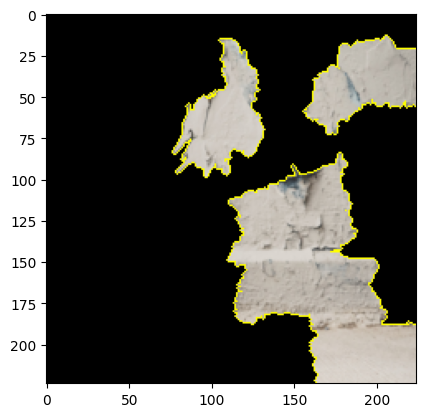

In [9]:
# Plot mask with negative contributions
temp, mask = explanation.get_image_and_mask(
    label=explanation.top_labels[label_to_explain],
    positive_only=False,
    negative_only=True,
    num_features=10,
    hide_rest=True,
    min_weight=0,
)
normalized_temp = temp / 255.0
img_boundry2 = mark_boundaries(normalized_temp, mask)
plt.imshow(img_boundry2)

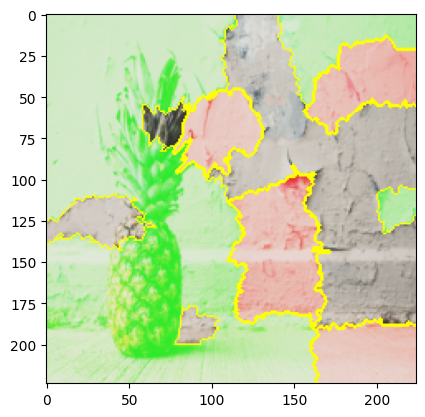

In [10]:
# Plot mask with both positive and negative contributions
temp, mask = explanation.get_image_and_mask(
    label=explanation.top_labels[label_to_explain],
    positive_only=False,
    negative_only=False,
    num_features=20, # increased to show more superpixels
    hide_rest=False,
    min_weight=0,
)
normalized_temp = temp/255.0
img_boundry3 = mark_boundaries(normalized_temp, mask)
plt.imshow(img_boundry3)

<font color='green'>

#### Question 3: Which are the pros and cons of LIME?

<font color='grey'>

#### Your Answer: 
Pros of LIME for Images:
- Model Agnosticism: Works with any ML model.
- Local Explanations: Provides insights for individual instances.
- Human Interpretability: Generates human-readable explanations.
- Versatility: Applicable to various data types.
  
Cons of LIME for Images:
- Sensitivity to Parameters: Parameter choices impact results (for example segmentation algorithm for superpixel definition, distance metric for superpixel weights, number of perturbed images, kernel_width/regularization surrogate model).
- Local Approximation: Captures local, not global, model behavior.
- Interpretability Challenges: Visualizations may be complex.
- Computational Cost: Can be resource-intensive.


<font color='green'>

#### Question 4: How do you think that the number of perturbed samples influences the stability of LIME explanations for image predictions?

<font color='grey'>

#### Your Answer:
Increasing the number of perturbed samples generally improves stability but comes at the cost of increased computation time. A balance is needed based on the desired level of stability and available resources.

<font color='green'>

#### Question 5: In the context of LIME for images, why do we perturb the input image by changing regions (superpixels) before generating explanations?

<font color='grey'>

#### Your Answer:
Perturbing the image helps understand the model's sensitivity to different regions, allowing LIME to approximate the local decision boundary around a specific instance.  

--------

## Extra Material: LIME for another image

Now, let's apply the whole procedure to another image. 
In this picture, we encounter both a dog and a cat. Let's reiterate the process of conducting inference and employing LIME. 
Printing the output for the top 10 predicted classes, we notice that the leading predictions include species like lynx or various other types of cats, with the initial dog prediction appearing at the seventh. Our focus will be to compare the LIME outcomes for the first and seventh classes. This comparison aims to shed light on why the model perceives a lynx or a cat species (class 0) in the image or a dog (class 6).

In [11]:
import json
import requests

path_to_img = '../data/images/cat_and_dog.jpg'
img = utils.read_image_PIL(path_to_img)

# Make prediction and print top-10 classes and labels
pred = utils.batch_predict([pill_transf(img)], model)

# Fetch ImageNet class labels
imagenet_classes_url = 'https://raw.githubusercontent.com/anishathalye/imagenet-simple-labels/master/imagenet-simple-labels.json'
response = requests.get(imagenet_classes_url)
class_labels = json.loads(response.text)

# Getting the top 10 predicted classes and their probabilities
top_10_classes = pred.squeeze().argsort()[-10:][::-1]  # Indices of top 5 classes
print("Top 10 predicted classes with their label and class names:")
for i in range(10):
    class_idx = top_10_classes[i]
    class_name = class_labels[class_idx]
    print(f"Class {i}: label {class_idx} - {class_name}")


Top 10 predicted classes with their label and class names:
Class 0: label 287 - lynx
Class 1: label 282 - tiger cat
Class 2: label 281 - tabby cat
Class 3: label 292 - tiger
Class 4: label 285 - Egyptian Mau
Class 5: label 286 - cougar
Class 6: label 263 - Pembroke Welsh Corgi
Class 7: label 273 - dingo
Class 8: label 264 - Cardigan Welsh Corgi
Class 9: label 291 - lion


In [12]:
# Define explainer
explainer = lime_image.LimeImageExplainer()
explanation = explainer.explain_instance(image=np.array(pill_transf(img)), 
                                         classifier_fn=lambda images: utils.batch_predict(images, model), 
                                         top_labels=10, 
                                         hide_color=None, 
                                         num_samples=1000,
                                         random_seed=42) 

  0%|          | 0/1000 [00:00<?, ?it/s]

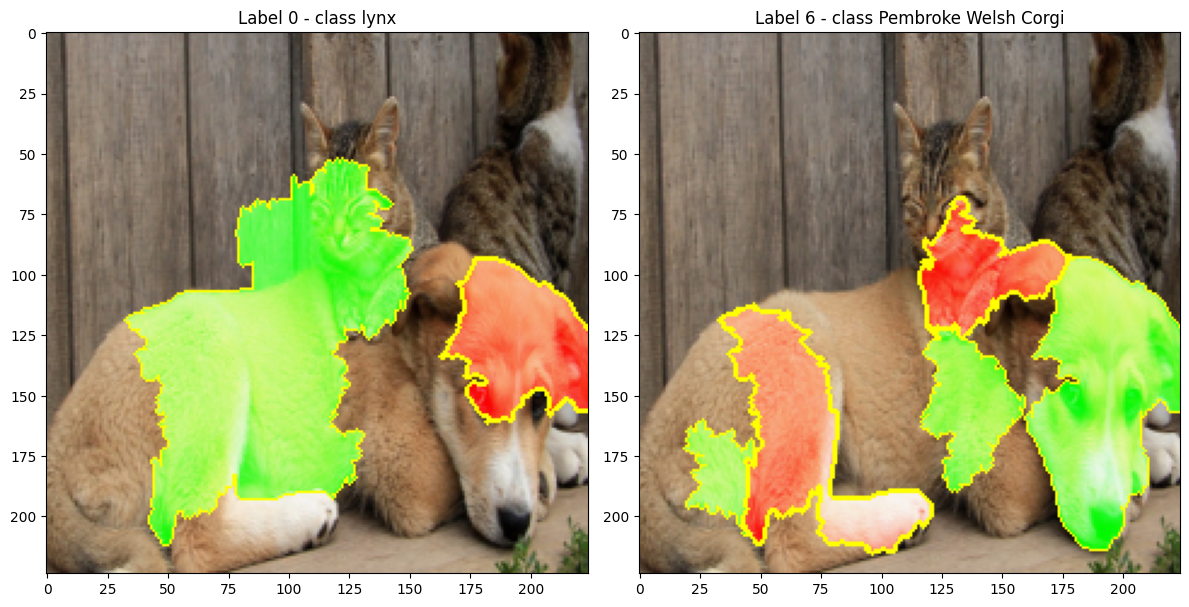

In [13]:
# Plot mask with positive contributions
label_to_explain = 0
temp, mask = explanation.get_image_and_mask(
    label=explanation.top_labels[label_to_explain],
    positive_only=False,
    negative_only=False,
    num_features=5,
    hide_rest=False,
    min_weight=0,
)
normalized_temp = temp / 255.0
img_boundry0 = mark_boundaries(normalized_temp, mask)

label_to_explain = 6
temp, mask = explanation.get_image_and_mask(
    label=explanation.top_labels[label_to_explain],
    positive_only=False,
    negative_only=False,
    num_features=10,
    hide_rest=False,
    min_weight=0,
)
normalized_temp = temp / 255.0
img_boundry6 = mark_boundaries(normalized_temp, mask)
fig, axes = plt.subplots(1, 2, figsize=(12, 6))  # Creating a figure with two subplots

# Plotting the first image (label_to_explain = 0)
axes[0].imshow(img_boundry0)
axes[0].set_title(f"Label 0 - class {class_labels[287]}")

# Plotting the second image (label_to_explain = 6)
axes[1].imshow(img_boundry6)
axes[1].set_title(f"Label 6 - class {class_labels[263]}")

plt.tight_layout()  # Adjusting layout for better spacing
plt.show()  # Displaying the plot